In [1]:
import os
import math
import json
import random
import numpy as np
import pandas as pd
from typing import Dict, Tuple

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import StandardScaler


# ---- Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, auc)

In [2]:
# -------------------------------------------------------------
# CONFIG
# -------------------------------------------------------------

CONFIG = {
    "IMG_DIRS": [
         r"C:\Users\User\Desktop\ds533\ham\HAM10000_images_part_1",
        r"C:\Users\User\Desktop\ds533\ham\HAM10000_images_part_2",
    ],
    "METADATA_CSV": r"C:\Users\User\Desktop\ds533\ham\HAM10000_metadata.csv",  # columns include: image_id, dx, age, sex, localization
    "IMG_SIZE": 224, 
    "BATCH": 32, 
    "EPOCHS": 50, #50(B0)
    "BACKBONE": "EfficientNetB0", # Keep B0 for VRAM 16GB
    "MIXED_PRECISION": True,     # Set False if you hit numeric issues
    "OUTPUT_DIR": r"C:\Users\User\Desktop\ds533\outputs_ham10000 case4paul",
    "SEED": 42,
}


os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

# Silence TF INFO logs (optional)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Mixed precision (recommended on modern GPUs)
if CONFIG["MIXED_PRECISION"]:
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy("mixed_float16")
    except Exception as e:
        print("[WARN] Mixed precision not available:", e)

In [3]:
# -------------------------------------------------------------
# LABELS
# -------------------------------------------------------------
CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}

# -------------------------------------------------------------
# LOAD METADATA & BUILD DATAFRAME
# -------------------------------------------------------------

def collect_image_paths(img_dirs):
    paths = []
    for d in img_dirs:
        if os.path.isdir(d):
            for fn in os.listdir(d):
                if fn.lower().endswith((".jpg", ".jpeg", ".png")):
                    paths.append(os.path.join(d, fn))
    return paths

In [4]:
all_paths = collect_image_paths(CONFIG["IMG_DIRS"])
print(f"Found {len(all_paths)} image files from provided folders.")

# Load metadata
md = pd.read_csv(CONFIG["METADATA_CSV"])  # expects columns: image_id, dx(label), age, sex, localization

# map image_id -> full path
# image files names are like ISIC_0024306.jpg ; metadata has image_id without extension
name2path: Dict[str, str] = {}
for p in all_paths:
    base = os.path.basename(p)
    stem = os.path.splitext(base)[0]
    name2path[stem] = p

# Build dataframe by joining metadata with resolved paths
# Filter to our 7 dx classes
md = md[md["dx"].isin(CLASSES)].copy()
md["label_idx"] = md["dx"].map(CLASS2IDX).astype(int)

# Fix pandas chained assignment: assign back safely
if md["age"].isna().all():
    # Rare case, fallback to 45
    md["age"] = 45
else:
    md["age"] = md["age"].fillna(md["age"].median())

# Normalize categorical entries
md["sex"] = md["sex"].fillna("unknown").str.lower()
md["localization"] = md["localization"].fillna("unknown").str.lower()

# Resolve paths; drop rows with missing files
md["image_path"] = md["image_id"].map(name2path)
md = md[~md["image_path"].isna()].copy()

print("Classes:", CLASSES)
print("Total images:", len(md))

# -------------------------------------------------------------
# STRATIFIED SPLIT 80/10/10
# -------------------------------------------------------------
train_df, temp_df = train_test_split(
    md, test_size=0.2, stratify=md["label_idx"], random_state=CONFIG["SEED"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label_idx"], random_state=CONFIG["SEED"]
)
print(f"Split -> train:{len(train_df)}  val:{len(val_df)}  test:{len(test_df)}")

# -------------------------------------------------------------
# METADATA ENCODING (age scaling, one-hots)
# -------------------------------------------------------------
# Fit encoders on *all* data to keep consistent dimensions
sex_values = sorted(md["sex"].unique().tolist())
loc_values = sorted(md["localization"].unique().tolist())
SEX2IDX = {s: i for i, s in enumerate(sex_values)}
LOC2IDX = {l: i for i, l in enumerate(loc_values)}

age_scaler = StandardScaler()
age_scaler.fit(md[["age"]].values.astype(np.float32))

meta_dim = 1 + len(SEX2IDX) + len(LOC2IDX)  # age + sex one-hot + loc one-hot

# Helper to convert one row -> meta vector

Found 10015 image files from provided folders.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Total images: 10015
Split -> train:8012  val:1001  test:1002


In [5]:
def row_to_meta(row) -> np.ndarray:
    age = row["age"]
    sex = row["sex"]
    loc = row["localization"]

    age_scaled = age_scaler.transform([[float(age)]])[0, 0]

    sex_oh = np.zeros(len(SEX2IDX), dtype=np.float32)
    sex_oh[SEX2IDX.get(sex, 0)] = 1.0

    loc_oh = np.zeros(len(LOC2IDX), dtype=np.float32)
    loc_oh[LOC2IDX.get(loc, 0)] = 1.0

    return np.concatenate([[age_scaled], sex_oh, loc_oh]).astype(np.float32)

# Build arrays for tf.data

def build_np_arrays(df):
    paths = df["image_path"].tolist()
    labels = df["label_idx"].astype(np.int32).values
    metas = np.vstack([row_to_meta(r) for _, r in df.iterrows()])
    return np.array(paths), metas, labels

In [6]:
train_paths, train_meta, train_y = build_np_arrays(train_df)
val_paths,   val_meta,   val_y   = build_np_arrays(val_df)
test_paths,  test_meta,  test_y  = build_np_arrays(test_df)

# Save label mapping for later inference
with open(os.path.join(CONFIG["OUTPUT_DIR"], "class_indices.json"), "w", encoding="utf-8") as f:
    json.dump({i: c for c, i in CLASS2IDX.items()}, f, ensure_ascii=False, indent=2)

# -------------------------------------------------------------
# TF.DATA PIPELINES
# -------------------------------------------------------------
IMG_SIZE = CONFIG["IMG_SIZE"]

@tf.function
def preprocess_image(path):
    img_bytes = tf.io.read_file(path)
    # Force decode to 3 channels to match ImageNet weights
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32)
    # EfficientNet expects [0,255] then preprocess_input; if you prefer, use rescaling(1/255.) + normalization below
    return img

# Augment
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomTranslation(0.2, 0.2, fill_mode="nearest"),
    layers.RandomShear(0.2, fill_mode="nearest"),
    # layers.RandomFlip("horizontal_and_vertical"),
    # layers.RandomRotation(0.1),                 # ~±10°
    # layers.RandomTranslation(0.1, 0.1),        # 10% shift
    # layers.RandomZoom((-0.1, 0.1)),            # zoom in/out
], name="augment")

# EfficientNetB0 preprocess
try:
    # EfficientNetV2 ถูกเพิ่มเข้ามาใน keras.applications ใน TensorFlow เวอร์ชันใหม่ๆ
    from tensorflow.keras.applications import efficientnet_v2
    effnet_preprocess = efficientnet_v2.preprocess_input
except Exception:
    # Fallback: simple rescale to [0,1]
    effnet_preprocess = lambda x: x / 255.0

In [7]:
def make_dataset(paths, metas, labels, training: bool, batch_size: int):
    ds = tf.data.Dataset.from_tensor_slices((paths, metas, labels))

    def _map(path, meta, y):
        img = preprocess_image(path)
        if training:
            img = augment(img, training=True)
        # Apply preprocess (expects float32)
        img = effnet_preprocess(img)
        return {"image": img, "meta": meta}, y

    if training:
        ds = ds.shuffle(4096, seed=CONFIG["SEED"], reshuffle_each_iteration=True)
    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Per-class datasets for oversampling (replication)

def make_per_class_datasets(paths, metas, labels, batch):
    per_class = []
    paths = np.array(paths)
    metas = np.array(metas)
    labels = np.array(labels)
    for c in range(len(CLASSES)):
        idx = np.where(labels == c)[0]
        ds_c = tf.data.Dataset.from_tensor_slices((paths[idx], metas[idx], labels[idx]))
        ds_c = ds_c.shuffle(len(idx), seed=CONFIG["SEED"], reshuffle_each_iteration=True)
        ds_c = ds_c.repeat()  # allow infinite sampling
        per_class.append(ds_c)
    # Equal weights for each class
    weights = [1.0 / len(CLASSES)] * len(CLASSES)

    def _map(path, meta, y):
        img = preprocess_image(path)
        img = augment(img, training=True)
        img = effnet_preprocess(img)
        return {"image": img, "meta": meta}, y

    balanced = tf.data.Dataset.sample_from_datasets(per_class, weights=weights, seed=CONFIG["SEED"])
    balanced = balanced.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    balanced = balanced.batch(batch).prefetch(tf.data.AUTOTUNE)
    return balanced

In [8]:
# Build datasets
train_ds_balanced = make_per_class_datasets(train_paths, train_meta, train_y, CONFIG["BATCH"])  # Oversampled
val_ds  = make_dataset(val_paths, val_meta, val_y, training=False, batch_size=CONFIG["BATCH"]) 
test_ds = make_dataset(test_paths, test_meta, test_y, training=False, batch_size=CONFIG["BATCH"]) 


In [9]:
# -------------------------------------------------------------
# MODEL
# -------------------------------------------------------------
from tensorflow.keras.applications import EfficientNetV2B0 
# หรือใช้
# from tensorflow.keras.applications import EfficientNetV2B0 as EfficientNetB0 
# เพื่อลดการแก้ไขโค้ดส่วนล่าง (แต่ในตัวอย่างนี้ขอเปลี่ยนชื่อตรงๆ)

# Inputs (เหมือนเดิม)
img_in = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
meta_in = layers.Input(shape=(meta_dim,), name="meta")

# Backbone (ใช้ EfficientNetV2B0)
# ถ้าต้องการใช้ ImageNet weights ให้ตั้งค่า weights="imagenet"
base = EfficientNetV2B0(include_top=False, weights="imagenet", input_tensor=img_in, pooling="avg") 
img_feat = layers.Dropout(0.2, name="img_dropout")(base.output)

# Metadata branch (เหมือนเดิม)
m = layers.Dense(64, activation="relu")(meta_in)
m = layers.Dropout(0.2)(m)
m = layers.Dense(32, activation="relu")(m)

# Fuse branches (เหมือนเดิม)
h = layers.Concatenate(name="fuse")([img_feat, m])
h = layers.Dense(128, activation="relu")(h)
h = layers.Dropout(0.3)(h)

# Output layer (เหมือนเดิม)
# IMPORTANT: in mixed precision, keep final dtype float32
out = layers.Dense(len(CLASSES), activation="softmax", dtype="float32", name="pred")(h)

model = Model(inputs=[img_in, meta_in], outputs=out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# -------------------------------------------------------------
# TRAINING
# -------------------------------------------------------------
steps_per_epoch = math.ceil(len(train_df) / CONFIG["BATCH"])  # with oversampling .repeat(), we need steps

ckpt_path = os.path.join(CONFIG["OUTPUT_DIR"], "best_efficientnetb0_meta.keras")
callbacks = [
    EarlyStopping(patience=8, restore_best_weights=True, monitor="val_accuracy"),
    ReduceLROnPlateau(patience=4, factor=0.2, monitor="val_loss", min_lr=1e-6),
    ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True)
]

history = model.fit(
    train_ds_balanced,
    validation_data=val_ds,
    epochs=CONFIG["EPOCHS"],
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks,
    verbose=1
)

# Save training history
hist_path = os.path.join(CONFIG["OUTPUT_DIR"], "train_history.json")
with open(hist_path, "w") as f:
    json.dump({k: [float(x) for x in v] for k, v in history.history.items()}, f, indent=2)

# -------------------------------------------------------------
# EVALUATION
# -------------------------------------------------------------
print("Evaluating on test set …")
results = model.evaluate(test_ds, verbose=1)
print(dict(zip(model.metrics_names, results)))

# Save model
final_path = os.path.join(CONFIG["OUTPUT_DIR"], "final_efficientnetb0_meta.keras")
model.save(final_path)
print("Saved model to:", final_path)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 16s 1us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ image[0][0]       │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 6,091,639 (23.24 MB)

 Trainable params: 6,031,031 (23.01 MB)

 Non-trainable params: 60,608 (236.75 KB)

Epoch 1/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5049s 20s/step - accuracy: 0.5565 - loss: 1.2008 - val_accuracy: 0.7243 - val_loss: 0.7888 - learning_rate: 1.0000e-04
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5123s 20s/step - accuracy: 0.7811 - loss: 0.6102 - val_accuracy: 0.7592 - val_loss: 0.6751 - learning_rate: 1.0000e-04
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5228s 21s/step - accuracy: 0.8264 - loss: 0.4752 - val_accuracy: 0.7732 - val_loss: 0.6071 - learning_rate: 1.0000e-04
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5247s 21s/step - accuracy: 0.8625 - loss: 0.3776 - val_accuracy: 0.7862 - val_loss: 0.6076 - learning_rate: 1.0000e-04
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5262s 21s/step - accuracy: 0.8889 - loss: 0.3176 - val_accuracy: 0.8132 - val_loss: 0.5081 - learning_rate: 1.0000e-04
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5272s 21s/step - accuracy: 0.9013 - loss: 0.2696 - val_accuracy: 0.7992 - val_loss: 0.5383 - learning_rate: 1.0000e-04
Epoch 7/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 5288s 

In [12]:
best_epoch = np.argmax(history.history["val_accuracy"])
print("Best epoch: %d" % (best_epoch,))
best_val_acc = history.history["val_accuracy"][best_epoch]
print("Best validation accuracy: %.4f" % (best_val_acc,))
best_train_acc = history.history["accuracy"][best_epoch]
print("Best training accuracy: %.4f" % (best_train_acc,))
total_epoch = len(history.history["accuracy"])
print("Total epochs: %d" % (total_epoch,))

Best epoch: 10
Best validation accuracy: 0.8472
Best training accuracy: 0.9490
Total epochs: 19


In [13]:
# แสดง summary ของโมเดล
model.summary()

# --- คำนวณจำนวนพารามิเตอร์ทั้งหมด ---
total_params = model.count_params()
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_params = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])



# --- รวมทุกเลเยอร์ ---
total_layers = len(model.layers)

# --- แสดงผล ---
print("\n📊 Model Architecture Summary 📊")
print(f"Total Trainable Parameters: {trainable_params:,}")
print(f"Total Layers: {total_layers}")
print(f"Non-trainable Parameters: {non_trainable_params:,}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ image[0][0]       │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 18,153,707 (69.25 MB)

 Trainable params: 6,031,031 (23.01 MB)

 Non-trainable params: 60,608 (236.75 KB)

 Optimizer params: 12,062,068 (46.01 MB)


📊 Model Architecture Summary 📊
Total Trainable Parameters: 6,031,031
Total Layers: 280
Non-trainable Parameters: 60,608


In [16]:
model.get_layer("fuse").output.shape


(None, 1312)


================= TRAINING SUMMARY =================
Epochs run          : 19
Best Val Accuracy   : 0.8472 (Epoch 11)
Final Train Accuracy: 0.9613
Final Val Accuracy  : 0.8442



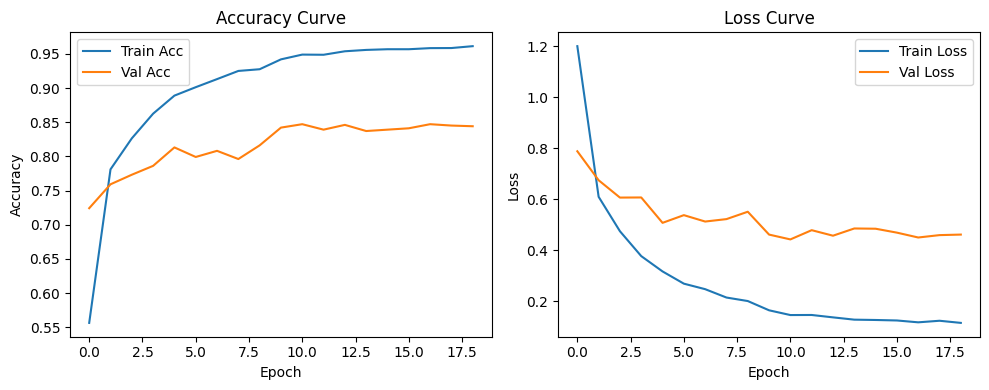


================= TEST EVALUATION ==================
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 887ms/step - accuracy: 0.8493 - loss: 0.4071
Test Accuracy : 0.8493
Test Loss     : 0.4071

32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 972ms/step


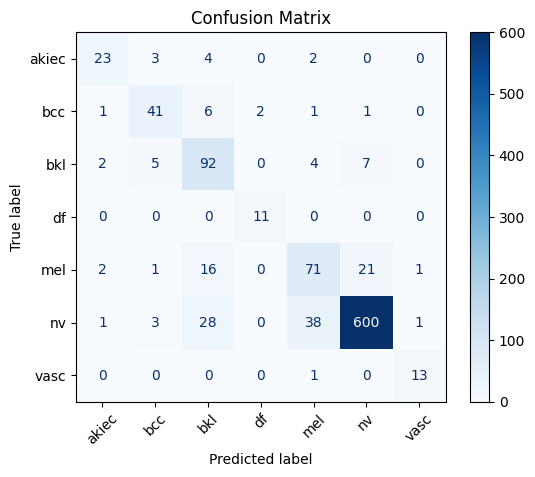


================= CLASSIFICATION REPORT =================
              precision    recall  f1-score   support

       akiec       0.79      0.72      0.75        32
         bcc       0.77      0.79      0.78        52
         bkl       0.63      0.84      0.72       110
          df       0.85      1.00      0.92        11
         mel       0.61      0.63      0.62       112
          nv       0.95      0.89      0.92       671
        vasc       0.87      0.93      0.90        14

    accuracy                           0.85      1002
   macro avg       0.78      0.83      0.80      1002
weighted avg       0.86      0.85      0.85      1002



In [17]:
# -------------------------------------------------------------
# REPORT & VISUALIZATION
# -------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# === 1. สรุปข้อมูลจาก training history ===
hist = history.history
epochs_ran = len(hist["accuracy"])
best_val_acc = max(hist["val_accuracy"])
best_epoch = np.argmax(hist["val_accuracy"]) + 1
final_train_acc = hist["accuracy"][-1]
final_val_acc = hist["val_accuracy"][-1]

print("\n================= TRAINING SUMMARY =================")
print(f"Epochs run          : {epochs_ran}")
print(f"Best Val Accuracy   : {best_val_acc:.4f} (Epoch {best_epoch})")
print(f"Final Train Accuracy: {final_train_acc:.4f}")
print(f"Final Val Accuracy  : {final_val_acc:.4f}")
print("====================================================\n")

# === 2. Plot Learning Curves ===
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(hist["accuracy"], label="Train Acc")
plt.plot(hist["val_accuracy"], label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist["loss"], label="Train Loss")
plt.plot(hist["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# === 3. Evaluate on Test Set ===
print("\n================= TEST EVALUATION ==================")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")
print("====================================================\n")

# === 4. Confusion Matrix & Classification Report ===
# หมายเหตุ: ต้องแน่ใจว่า test_ds มี (x, y)
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = model.predict(test_ds, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("\n================= CLASSIFICATION REPORT =================")
print(classification_report(y_true, y_pred_classes, target_names=CLASSES))


32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 540ms/step

================= ADVANCED METRICS =================
Macro Precision : 0.7815
Macro Recall    : 0.8286
Macro F1-score  : 0.8015
Weighted F1     : 0.8536
ROC-AUC (macro, OvR): 0.9778



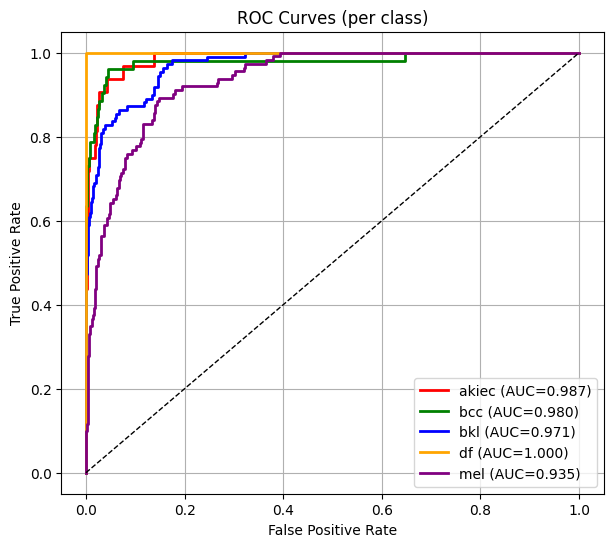

In [18]:
# -------------------------------------------------------------
# ADVANCED METRICS (F1, ROC-AUC, Precision, Recall)
# -------------------------------------------------------------
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, auc
)

# Predict
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# === 1. Basic Scores ===
precision_macro = precision_score(y_true, y_pred, average="macro")
recall_macro = recall_score(y_true, y_pred, average="macro")
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")

print("\n================= ADVANCED METRICS =================")
print(f"Macro Precision : {precision_macro:.4f}")
print(f"Macro Recall    : {recall_macro:.4f}")
print(f"Macro F1-score  : {f1_macro:.4f}")
print(f"Weighted F1     : {f1_weighted:.4f}")

# === 2. ROC-AUC (multi-class) ===
# ใช้ one-vs-rest strategy
try:
    y_true_bin = tf.keras.utils.to_categorical(y_true, num_classes=len(CLASSES))
    auc_macro = roc_auc_score(y_true_bin, y_pred_prob, average="macro", multi_class="ovr")
    print(f"ROC-AUC (macro, OvR): {auc_macro:.4f}")
except Exception as e:
    print("ROC-AUC calculation skipped:", e)

print("====================================================\n")

# === 3. Plot ROC Curve (ตัวอย่างแสดงแค่ 3 class แรก ถ้ามีหลาย class มาก) ===
from sklearn.preprocessing import label_binarize
from itertools import cycle

y_bin = label_binarize(y_true, classes=range(len(CLASSES)))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(CLASSES)):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
colors = cycle(["red", "green", "blue", "orange", "purple", "brown"])
for i, color in zip(range(min(5, len(CLASSES))), colors):  # วาดแค่ไม่เกิน 5 class
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"{CLASSES[i]} (AUC={roc_auc[i]:.3f})")

plt.plot([0,1], [0,1], "k--", lw=1)
plt.title("ROC Curves (per class)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
